In [92]:
import os
import random
import torch
import torch.nn as nn
import torchvision
from torchinfo import summary
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from itertools import combinations

In [93]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1, stride=1),    # (1, 28, 28) -> (32, 28, 28)
            nn.MaxPool2d(kernel_size=2, stride=2),    # (32, 28, 28) -> (32, 14, 14)
            nn.ReLU(),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1, stride=1),    # (32, 14, 14) -> (64, 14, 14)
            nn.MaxPool2d(kernel_size=2, stride=2),    # (64, 14, 14) -> (64, 7, 7)
            nn.ReLU(),
        )

        self.mu_layer = nn.Linear(64*7*7, latent_dim)    # (1, 64*7*7) -> (1, latent_dim)
        self.logvar_layer = nn.Linear(64*7*7, latent_dim)    # (1, 64*7*7) -> (1, latent_dim)
    
    def forward(self, img):
        x = self.conv_layers(img)
        x = x.view(x.size(0), -1)    # (64, 7, 7) -> (1, 64*7*7)

        mu = self.mu_layer(x)
        logvar = self.logvar_layer(x)

        return mu, logvar

In [94]:
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.fcnn_layer = nn.Linear(latent_dim, 64*7*7)    # (1, latent_dim) -> (1, 64*7*7)

        self.conv_layers = nn.Sequential(
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=4, padding=1, stride=2),    # (64, 7, 7) -> (32, 14, 14)
            nn.ReLU(),

            nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=4, padding=1, stride=2),    # (32, 14, 14) -> (3, 28, 28)
            nn.Sigmoid(),
        )
    
    def forward(self, latent):
        x = self.fcnn_layer(latent)
        x = x.view(x.size(0), 64, 7, 7)    # (1, 64*7*7) -> (64, 7, 7)

        img = self.conv_layers(x)
        return img

In [95]:
class VAE(nn.Module):
    def __init__(self, latent_dim, generator, eps):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
        self.generator = generator
        self.eps = eps
    
    def forward(self, img):
        mu, logvar = self.encoder(img)

        # We will try to make model learn roation invariance by perturbing the latent randomly using the generator
        coin_toss = random.random()
        mu += coin_toss*self.eps*self.generator(mu).squeeze(0)    # The idea is that decoder will see a variety of inputs but it will always have to reconstruct the original

        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        
        out = self.decoder(z)
        return out, mu, logvar

In [96]:
class VAELoss(nn.Module):
    def __init__(self, beta):
        super().__init__()
        self.beta = beta
        self.mse_loss = nn.MSELoss(reduction="sum")
    
    def forward(self, img, out, mu, logvar):
        reconstruction_loss = self.mse_loss(img, out)
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

        loss = (reconstruction_loss + self.beta * kl_loss) / img.shape[0]
        reconstruction_loss /= img.shape[0]
        kl_loss /= img.shape[0]
        
        return loss, reconstruction_loss, kl_loss

In [97]:
def train_one_epoch(model, train_dataloader, test_dataloader, loss_func, optimizer, device):
    train_loss = 0
    train_reconstruction_loss = 0
    train_kl_loss = 0

    model.train()
    for img, label in tqdm(train_dataloader, desc="Training"):
        img = img.to(device)
        label = label.to(device)

        out, mu, logvar = model(img)

        optimizer.zero_grad()
        loss, reconstruction_loss, kl_loss = loss_func(img, out, mu, logvar)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_reconstruction_loss += reconstruction_loss.item()
        train_kl_loss += kl_loss.item()
    
    test_loss = 0
    test_reconstruction_loss = 0
    test_kl_loss = 0

    model.eval()
    with torch.no_grad():
        for img, label in tqdm(test_dataloader, desc="Validating"):
            img = img.to(device)
            label = label.to(device)

            out, mu, logvar = model(img)
            loss, reconstruction_loss, kl_loss = loss_func(img, out, mu, logvar)

            test_loss += loss.item()
            test_reconstruction_loss += reconstruction_loss.item()
            test_kl_loss += kl_loss.item()
    
    train_loss /= len(train_dataloader)  
    train_reconstruction_loss /= len(train_dataloader)  
    train_kl_loss /= len(train_dataloader)  
    test_loss /= len(test_dataloader)  
    test_reconstruction_loss /= len(test_dataloader)   
    test_kl_loss /= len(test_dataloader)

    return train_loss, train_reconstruction_loss, train_kl_loss, test_loss, test_reconstruction_loss, test_kl_loss


In [98]:
def visualize(model, test_dataloader, epoch, device):
    sample_original = []
    sample_in = []
    sample_out = []
    all_mu = []
    all_labels = []

    model.eval()
    batch = 0
    with torch.no_grad():
        for img, label in tqdm(test_dataloader, desc="Visualizing"):
            if (batch % 4 != 0):    # We only use 25% of test data for visualization
                batch += 1
                continue
            label = label.to(device)
            original_img = img.clone().to(device)

            # To test whether our idea worked, we will rotate the input slightly and check the visualization
            angles = [random.uniform(-30, 30) for k in range(img.shape[0])]
            img = torch.stack([torchvision.transforms.functional.rotate(img[i], angle) for i, angle in enumerate(angles)])
            img = img.to(device)

            out, mu, logvar = model(img)

            if (len(sample_in) == 0):    # The first batch will be visualized for reconstruction
                sample_in.append(img)
                sample_out.append(out)
                sample_original.append(original_img)
            
            all_mu.append(mu)
            all_labels.append(label)

            batch += 1
    
    sample_in = torch.cat(sample_in, dim=0)
    sample_out = torch.cat(sample_out, dim=0)
    sample_original = torch.cat(sample_original, dim=0)
    all_mu = torch.cat(all_mu, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    fig, axes = plt.subplots(3, 5, figsize=(12, 6))
    for i in range(5):
        axes[0, i].imshow(sample_original[i].squeeze(0).cpu(), cmap="gray")
        axes[0, i].set_title("input")
        axes[1, i].imshow(sample_in[i].squeeze(0).cpu(), cmap="gray")
        axes[1, i].set_title("perturbed input")
        axes[2, i].imshow(sample_out[i].squeeze(0).cpu(), cmap="gray")
        axes[2, i].set_title("output")
    
    plt.tight_layout()
    plt.savefig(f"bonus_results/reconstruction_epoch_{epoch}.png")
    plt.close()

    pca = PCA(n_components=2)
    all_mu_2d = pca.fit_transform(all_mu.cpu().numpy())
    
    plt.figure(figsize=(8,6)) 
    # scatter = plt.scatter(all_mu_2d[:,0], all_mu_2d[:,1], c=all_labels.cpu(), cmap="tab10",s=5)
    scatter = plt.scatter(all_mu_2d[:,0], all_mu_2d[:,1], c=all_labels.cpu(), cmap="coolwarm",s=5)

    # cbar = plt.colorbar(scatter, ticks=np.arange(10))
    # cbar.ax.set_yticklabels([f"{i}" for i in range(10)])
    cbar = plt.colorbar(scatter, ticks=[1,2])
    cbar.ax.set_yticklabels([1,2])
    plt.tight_layout
    plt.savefig(f"bonus_results/latent_space_{epoch}.png")
    plt.close()

In [99]:
def train(num_epochs, model, train_dataloader, test_dataloader, loss_func, optimizer, device, patience):
    train_losses = []
    train_reconstruction_losses = []
    train_kl_losses = []
    test_losses = []
    test_reconstruction_losses = []
    test_kl_losses = []

    best_test_loss = float("inf")
    patience_count = 0
    for epoch in range(num_epochs):
        train_loss, train_reconstruction_loss, train_kl_loss, test_loss, test_reconstruction_loss, test_kl_loss = train_one_epoch(model, train_dataloader, test_dataloader, loss_func, optimizer, device)

        train_losses.append(train_loss)
        train_reconstruction_losses.append(train_reconstruction_loss)
        train_kl_losses.append(train_kl_loss)
        test_losses.append(test_loss)
        test_reconstruction_losses.append(test_reconstruction_loss)
        test_kl_losses.append(test_kl_loss)

        visualize(model, test_dataloader, epoch, device)

        print(f"Epoch {epoch} | train_loss: {train_loss:.2f} | train_recon: {train_reconstruction_loss:.2f} | train_kl: {train_kl_loss:.2f} | test_loss: {test_loss:.2f}")

        if (test_loss < best_test_loss):
            patience_count = 0
            best_test_loss = test_loss
            torch.save(model.state_dict(), "bonus_results/best_model.pt")
        else:
            patience_count += 1
            if (patience_count >= patience):
                print("Early stopping")
                break

    return train_losses, train_reconstruction_losses, train_kl_losses, test_losses, test_reconstruction_losses, test_kl_losses

In [100]:
transforms = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device {device}")

train_data_raw = torchvision.datasets.MNIST(root="mnist", train=True, download=True, transform=transforms)
test_data_raw = torchvision.datasets.MNIST(root="mnist", train=False, download=True, transform=transforms)

indices = (train_data_raw.targets == 1) | (train_data_raw.targets == 2)
train_data_raw.data = train_data_raw.data[indices]
train_data_raw.targets = train_data_raw.targets[indices]

indices = (test_data_raw.targets == 1) | (test_data_raw.targets == 2)
test_data_raw.data = test_data_raw.data[indices]
test_data_raw.targets = test_data_raw.targets[indices]

# Since we deal only with 1 and 2, we can treat this as binary classification problem
train_data_raw.targets = (train_data_raw.targets == 2).long()
test_data_raw.targets  = (test_data_raw.targets == 2).long()

Using device cuda


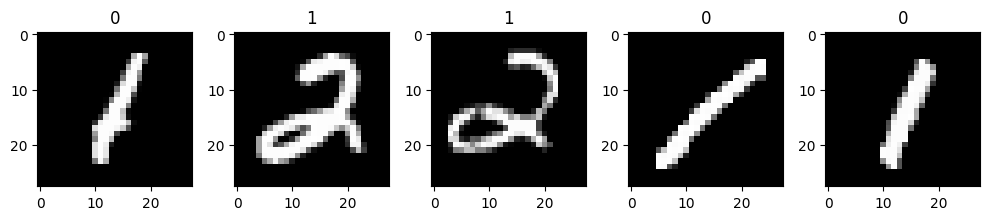

In [101]:
batch_size = 64
train_dataloader = DataLoader(train_data_raw, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=4)
test_dataloader = DataLoader(test_data_raw, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=4)

with torch.no_grad():
    for img, label in train_dataloader:
        fig, axes = plt.subplots(1, 5, figsize=(10, 12))
        for i in range(5):
            axes[i].imshow(img[i].squeeze(0), cmap="gray")
            axes[i].set_title(label[i].item())

        plt.tight_layout()
        plt.show()
        break

In [102]:
class SymmetricTransformationMLP(nn.Module):
    """   
    This is the transformation function G(x). For transforming our input x, we will use G(x) as a direction scaled by epsilon.
    """
    def __init__(self, latent_dim, num_transformers):
        super().__init__()
        self.num_transformers = num_transformers
        
        self.transformers = nn.ModuleList()
        for i in range(num_transformers):
            self.transformers.append(nn.Sequential(
                nn.Linear(latent_dim, 64),    # (1, latent_dim) -> (1, 64)
                nn.ReLU(),
                
                nn.Linear(64, latent_dim),    # (1, 64) -> (1, latent_dim)
            ))

    def forward(self, x):
        x_transformed_all = []
        for i in range(self.num_transformers):
            x_transformed = self.transformers[i](x)
            x_transformed = x_transformed.unsqueeze(0)    # The additional dimension will hold the concerned generator
            x_transformed_all.append(x_transformed)
        
        x_transformed_all = torch.cat(x_transformed_all, dim=0)
        return x_transformed_all

In [103]:
latent_dim = 4
num_transformers = 1

generator = SymmetricTransformationMLP(latent_dim, num_transformers)
generator = generator.to(device)
generator_model_path = "task3_results/best_generator.pt"
generator.load_state_dict(torch.load(generator_model_path))

# Freezing the VAE parameters
for p in generator.parameters():
    p.requires_grad = False

In [104]:
latent_dim = 4
eps = 1e-2
vae = VAE(latent_dim, generator, eps)
vae = vae.to(device)

In [105]:
os.makedirs("bonus_results", exist_ok=True)
num_epochs = 50
beta = 1
lr = 1e-4
patience = 5
loss_func = VAELoss(beta)
optimizer = torch.optim.Adam(vae.parameters(), lr=lr)

train_losses, train_reconstruction_losses, train_kl_losses, test_losses, test_reconstruction_losses, test_kl_losses = train(num_epochs, vae, train_dataloader, test_dataloader, loss_func, optimizer, device, patience)

Visualizing: 100%|██████████| 34/34 [00:00<00:00, 72.81it/s]


Epoch 0 | train_loss: 88.68 | train_recon: 78.00 | train_kl: 10.67 | test_loss: 55.78


Visualizing: 100%|██████████| 34/34 [00:00<00:00, 70.82it/s]


Epoch 1 | train_loss: 48.02 | train_recon: 39.28 | train_kl: 8.75 | test_loss: 42.07


Visualizing: 100%|██████████| 34/34 [00:00<00:00, 69.67it/s]


...

Epoch 47 | train_loss: 24.19 | train_recon: 18.59 | train_kl: 5.59 | test_loss: 24.02


Visualizing: 100%|██████████| 34/34 [00:00<00:00, 72.29it/s]


Epoch 48 | train_loss: 24.14 | train_recon: 18.55 | train_kl: 5.59 | test_loss: 23.97


Visualizing: 100%|██████████| 34/34 [00:00<00:00, 72.54it/s]


Epoch 49 | train_loss: 24.12 | train_recon: 18.53 | train_kl: 5.59 | test_loss: 23.81


In [106]:
plt.figure()
plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")
plt.title("Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("bonus_results/total_loss.png")
plt.close()

plt.figure()
plt.plot(train_kl_losses, label="train")
plt.plot(test_kl_losses, label="test")
plt.title("KL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("bonus_results/kl_loss.png")
plt.close()

plt.figure()
plt.plot(train_reconstruction_losses, label="train")
plt.plot(test_reconstruction_losses, label="test")
plt.title("Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("bonus_results/reconstruction_loss.png")
plt.close()